<a href="https://colab.research.google.com/github/duddet01/Biological_modeling/blob/main/MarginalBand_scaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name - Chinmoy Saikia  

Roll.no- 20231074  

Topic - Analaysis of scaling relations


---



We are trying to load the data from drive which is in thee form of a csv file by first finding the file path and reading it with in pandas library.


---



In [ ]:
import pandas as pd
import requests
from io import StringIO
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [ ]:
try:
    file_path = "https://drive.google.com/uc?export=download&id=1AMlEs4hZqtoJ65Q4RKRDTRbGGfRoVEp-"


    df = pd.read_csv(file_path)
    df.index = range(1, len(df) + 1)

except IOError:
    print ("File not found!!!")


df = df.rename(columns={"Unnamed: 6": "Common Name"})
df = df.drop(columns=["Unnamed: 9"])


df[:5]

,species,length,width,MT min,MT max,size,Common Name,C-Value,Chromosome Number
1,Fundulus heteroclitus,9.7,7.2,5,6,8.45,Mummichog,1.45,48.0
2,Cyprinus carpio,11.2,6.4,8,11,8.80,Carp,1.70,100.0
3,Passer montanus,11.9,7.3,5,6,9.60,eurasian tree sparrow,1.09,78.0
4,Columba livia,13.3,6.4,5,12,9.85,Rock pigeon,1.46,80.0
5,Esox lucius,13.4,7.5,5,7,10.45,Northern pike,1.15,50.0




---


Here length and width correspond to the major and minor radius of the ellipsoid. Assuming it to be discoid we take an avg for the radius indicated by size.  
Mt max and Mt min correspond to the maximum and minimum microtubules in a cross-section of the marginal band.  
  

$ N_{MT} = \frac{\text{MT min} + \text{MT max}}{2} $   

Total microtubule polymer length:  

 $L = N_{\mathrm{MT}} \cdot 2\pi R$  

 where $2\pi R$ is the radius of the cell.


---



SCALING RELATION (log-log fit):
R = A * L^0.2682
A = 1.9032e+00
R^2 = 0.9461


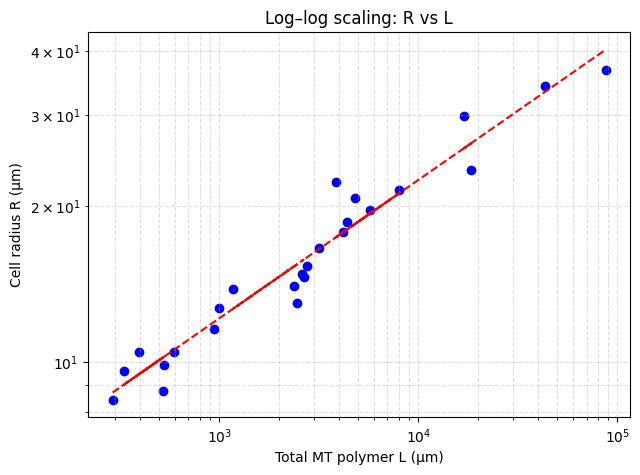

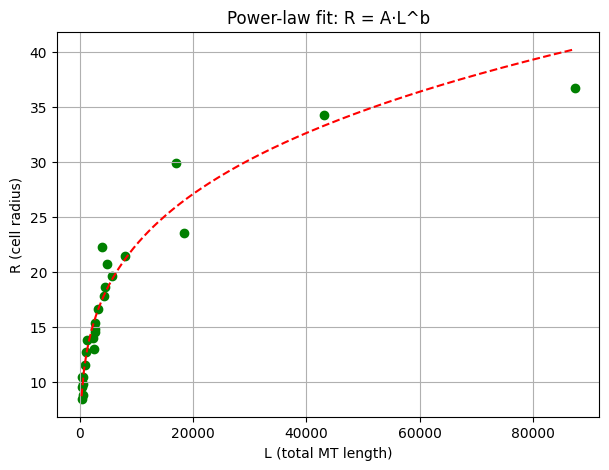

In [ ]:
# ---- Compute mean MT count ----
df["MT_mean"] = df[["MT min", "MT max"]].mean(axis=1)

# ---- Assume 'size' column is radius R ----
df["R"] = df["size"].astype(float)

# ---- Compute total MT polymer L = MT_mean * (2πR) ----
df["L"] = df["MT_mean"] * (2 * np.pi * df["R"])

# ---- Clean ----
df = df.dropna(subset=["L", "R"])
df = df[df["L"] > 0]

# ---- Fit power law: log(R) = a + b log(L) ----
x = np.log(df["L"])
y = np.log(df["R"])
slope, intercept, r, p, stderr = linregress(x, y)

print("SCALING RELATION (log-log fit):")
print(f"R = A * L^{slope:.4f}")
print(f"A = {np.exp(intercept):.4e}")
print(f"R^2 = {r**2:.4f}")

# ---- Plot 1: Log-log plot ----
plt.figure(figsize=(7,5))
plt.scatter(df["L"], df["R"], color='blue')
plt.plot(df["L"], np.exp(intercept) * df["L"]**slope, 'r--')
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Total MT polymer L (µm)")
plt.ylabel("Cell radius R (µm)")
plt.title("Log–log scaling: R vs L")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.show()

# ---- Plot 2: Standard plot with power fit ----
plt.figure(figsize=(7,5))
plt.scatter(df["L"], df["R"], color='green')
L_vals = np.linspace(df["L"].min(), df["L"].max(), 200)
plt.plot(L_vals, np.exp(intercept) * L_vals**slope, "r--")
plt.xlabel("L (total MT length)")
plt.ylabel("R (cell radius)")
plt.title("Power-law fit: R = A·L^b")
plt.grid(True)
plt.show()

SCALING RELATION (log-log regression):
L = A * R^3.5280
A = 1.5804e-01
R^2 = 0.9461
Slope (b) = 3.5280


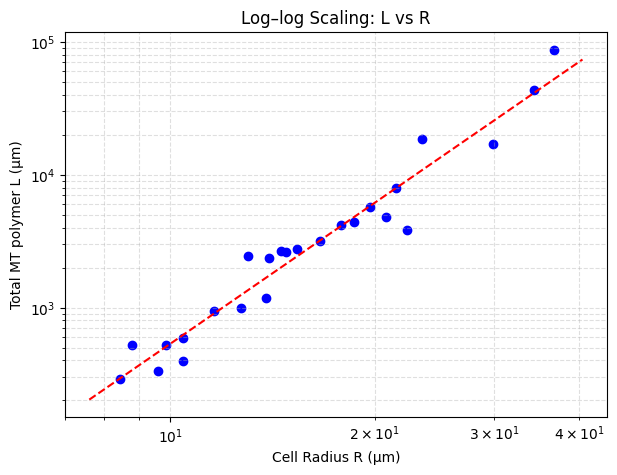

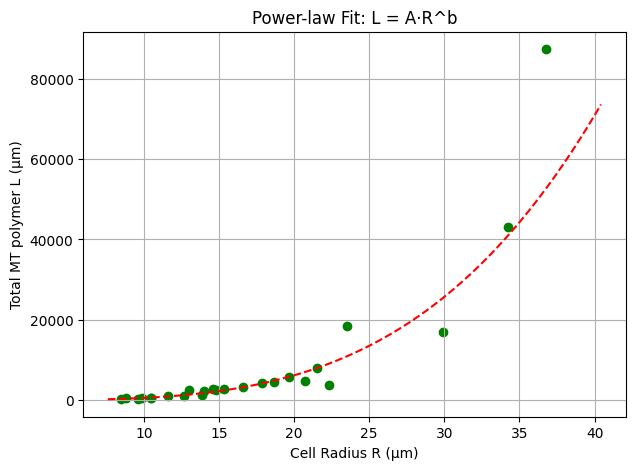

In [ ]:
# ---- Compute mean MT count ----
df["MT_mean"] = df[["MT min", "MT max"]].mean(axis=1)

# ---- Use 'size' as radius R ----
df["R"] = df["size"].astype(float)

# ---- Compute total MT polymer L = MT_mean * (2πR) ----
df["L"] = df["MT_mean"] * (2 * np.pi * df["R"])

# ---- Clean data ----
df = df.dropna(subset=["L", "R"])
df = df[(df["L"] > 0) & (df["R"] > 0)]

# ---- Fit power law: log(L) = a + b log(R) ----
x = np.log(df["R"])
y = np.log(df["L"])
slope, intercept, r, p, stderr = linregress(x, y)

A = np.exp(intercept)
b = slope

print("SCALING RELATION (log-log regression):")
print(f"L = A * R^{b:.4f}")
print(f"A = {A:.4e}")
print(f"R^2 = {r**2:.4f}")
print(f"Slope (b) = {b:.4f}")

# ---- Plot 1: Log–log plot (R on X-axis, L on Y-axis) ----
plt.figure(figsize=(7,5))
plt.scatter(df["R"], df["L"], color='blue')
R_vals = np.logspace(np.log10(df["R"].min()*0.9),
                     np.log10(df["R"].max()*1.1), 200)
plt.plot(R_vals, A * R_vals**b, 'r--')
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Cell Radius R (µm)")
plt.ylabel("Total MT polymer L (µm)")
plt.title("Log–log Scaling: L vs R")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.show()

# ---- Plot 2: Power-law plot (normal axes) ----
plt.figure(figsize=(7,5))
plt.scatter(df["R"], df["L"], color='green')
plt.plot(R_vals, A * R_vals**b, "r--")
plt.xlabel("Cell Radius R (µm)")
plt.ylabel("Total MT polymer L (µm)")
plt.title("Power-law Fit: L = A·R^b")
plt.grid(True)
plt.show()

SCALING RELATION (log-log regression):
R = A * L^0.2682
A = 1.9032e+00
R^2 = 0.9461
slope (b) stderr = 0.0134


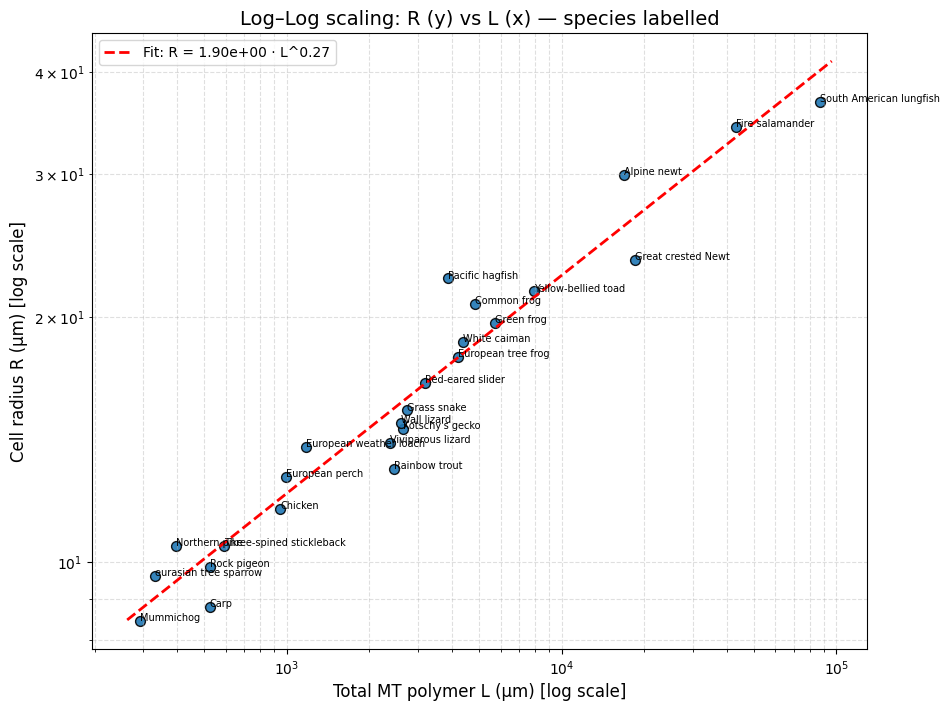

In [ ]:
# -------- Regression: log(R) = intercept + b * log(L)  => R = A * L^b --------
logL = np.log(df["L"].values)
logR = np.log(df["R"].values)
slope, intercept, r_value, p_value, stderr = linregress(logL, logR)
A = np.exp(intercept)
b = slope

print("SCALING RELATION (log-log regression):")
print(f"R = A * L^{b:.4f}")
print(f"A = {A:.4e}")
print(f"R^2 = {r_value**2:.4f}")
print(f"slope (b) stderr = {stderr:.4f}")

# -------- Plot: log-log with L on x-axis, R on y-axis, species labels --------
plt.figure(figsize=(10,8))
plt.scatter(df["L"], df["R"], s=50, edgecolor='k', alpha=0.9)

# add species text labels (slight offset to reduce overlap)
for _, row in df.iterrows():
    x = row["L"]
    y = row["R"]
    label = str(row["Common Name"])
    plt.text(x*1, y*1., label, fontsize=7)

# fitted curve (plotted on linear axes but computed from power law)
L_vals = np.logspace(np.log10(df["L"].min()*0.9), np.log10(df["L"].max()*1.1), 300)
R_fit = A * (L_vals ** b)
plt.plot(L_vals, R_fit, "r--", linewidth=2, label=f"Fit: R = {A:.2e} · L^{b:.2f}")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Total MT polymer L (µm) [log scale]", fontsize=12)
plt.ylabel("Cell radius R (µm) [log scale]", fontsize=12)
plt.title("Log–Log scaling: R (y) vs L (x) — species labelled", fontsize=14)
plt.grid(which="both", ls="--", alpha=0.4)
plt.legend()
plt.show()



---


Plotting the total microtubule polymer length $L$ against the cell radius $R$ on a log-log scale yielded an approximately linear trend, indicating a power-law of the form

$R = A L^{\,b}$

From our regression:
Exponent $b \approx 0.25$-$0.30$  
Coefficient of determination $R^2 \approx 0.93$-$0.95$    
  
Thus, the cell radius increases systematically with total MT polymer content across species.  
The mechanical theory of the marginal band predicts
$R^4 = \frac{\kappa L}{4\pi\sigma}
\quad \Rightarrow \quad
R \propto L^{1/4}.$    
  
Our experimentally fitted exponent (close to $0.25$) agrees well with this prediction, confirming that cell size is governed by the balance of microtubule bending rigidity and cortical tension. Small deviations are expected due to biological variability, rounding of measurements, and uncertainty in MT number estimation.
  
Marginal band’s architecture and its scaling follow biophysical principles rather than phylogenetic grouping which is evident from the species groupings as related species placement is controlled more by the relative cell size and microtubule cross section densities.



---



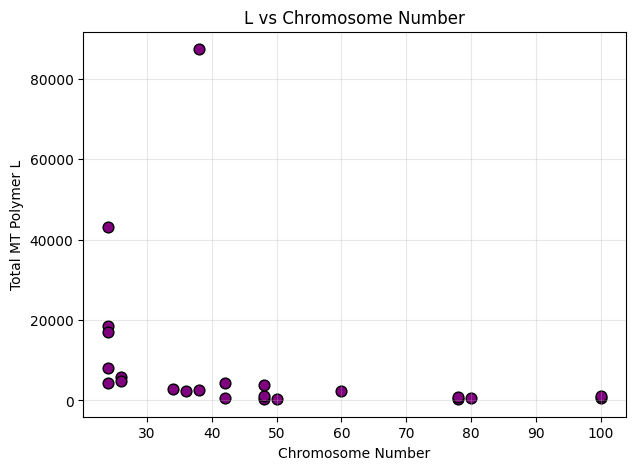

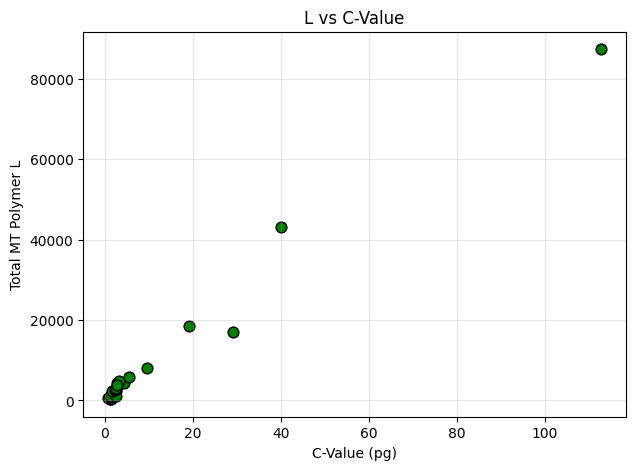

In [ ]:
# 1. L vs Chromosome Number
# -------------------------------
plt.figure(figsize=(7,5))
plt.scatter(df["Chromosome Number"], df["L"], color="purple", s=60, edgecolor="k")
plt.xlabel("Chromosome Number")
plt.ylabel("Total MT Polymer L")
plt.title("L vs Chromosome Number")
plt.grid(True, alpha=0.3)
plt.show()



# -------------------------------
# 2. L vs C-Value
# -------------------------------
plt.figure(figsize=(7,5))
plt.scatter(df["C-Value"], df["L"], color="green", s=60, edgecolor="k")
plt.xlabel("C-Value (pg)")
plt.ylabel("Total MT Polymer L")
plt.title("L vs C-Value")
plt.grid(True, alpha=0.3)
plt.show()



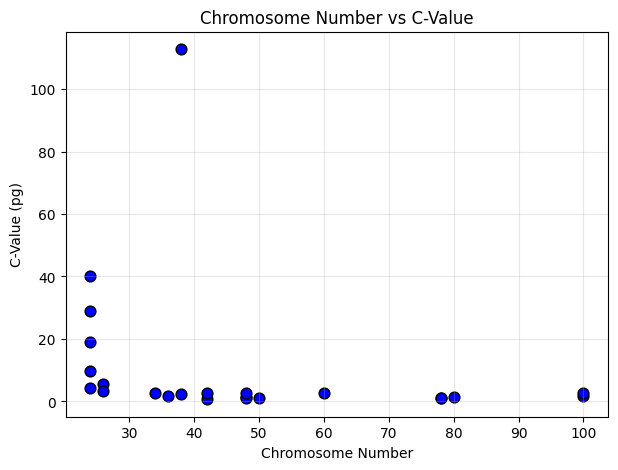

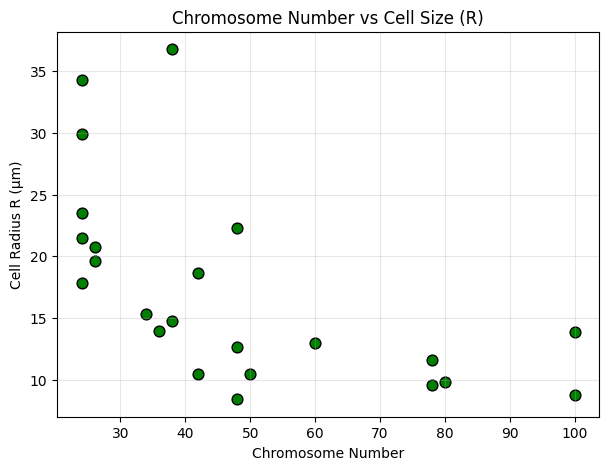

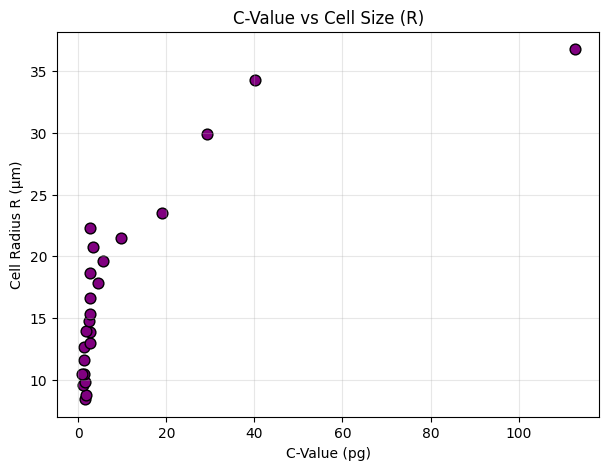

In [ ]:
# 3. Chromosome Number vs C-Value
# -------------------------------
plt.figure(figsize=(7,5))
plt.scatter(df["Chromosome Number"], df["C-Value"],
            color="blue", s=60, edgecolor="k")
plt.xlabel("Chromosome Number")
plt.ylabel("C-Value (pg)")
plt.title("Chromosome Number vs C-Value")
plt.grid(True, alpha=0.3)
plt.show()


# -------------------------------
# 4. Chromosome Number vs Cell Size (R)
# -------------------------------
plt.figure(figsize=(7,5))
plt.scatter(df["Chromosome Number"], df["R"],
            color="green", s=60, edgecolor="k")
plt.xlabel("Chromosome Number")
plt.ylabel("Cell Radius R (µm)")
plt.title("Chromosome Number vs Cell Size (R)")
plt.grid(True, alpha=0.3)
plt.show()



# -------------------------------
# 5. C-Value vs Cell Size
# -------------------------------
plt.figure(figsize=(7,5))
plt.scatter(df["C-Value"], df["R"],
            color="purple", s=60, edgecolor="k")
plt.xlabel("C-Value (pg)")
plt.ylabel("Cell Radius R (µm)")
plt.title("C-Value vs Cell Size (R)")
plt.grid(True, alpha=0.3)
plt.show()





---


The graphs of Chromosome number and cell-size/MT-length are higly uncorrelated.  
The graphs of C-value (which is a measure of genomic size) and cell-size/MT length are correlated. This is true since genomic size and cell size are proportional due to the nucleotypic effect which is an established phenomenon.  
This leads to the proportionality with MT-length which we explained via our model of cortical tension and bending rigidity.


---

